In [3]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
# Importar datos (colocarlo en colab)
df = pd.read_csv("Data_PI_regresion.csv")
df.head() # Los 5 primeras filas del dataset

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
0,29.8,7.4,76.4,87.0,28.97
1,22.9,4.3,88.8,74.9,21.85
2,21.9,10.4,87.7,65.7,37.43
3,27.4,7.8,55.7,79.0,26.32
4,30.2,6.9,42.3,62.9,26.08


In [7]:
df.info(verbose=True) # Información del dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperatura      5000 non-null   float64
 1   Horas_Operacion  5000 non-null   float64
 2   Carga            5000 non-null   float64
 3   Humedad          5000 non-null   float64
 4   Consumo_Energia  5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


In [10]:
df.describe() # Va a salir con todos los datos estadísticos
df.describe().round(1) # Lo mismo pero con con una decimal

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
count,5000.0,5000.0,5000.0,5000.0,5000.0
mean,26.5,7.0,65.0,65.1,26.0
std,4.9,2.9,20.3,14.3,5.6
min,18.0,2.0,30.0,40.0,9.1
25%,22.1,4.4,47.3,52.7,21.8
50%,26.5,7.0,65.7,65.0,26.1
75%,30.7,9.4,82.5,77.5,30.3
max,35.0,12.0,100.0,90.0,42.6


In [11]:
df.columns # Solo muestra las columnas

Index(['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad',
       'Consumo_Energia'],
      dtype='object')

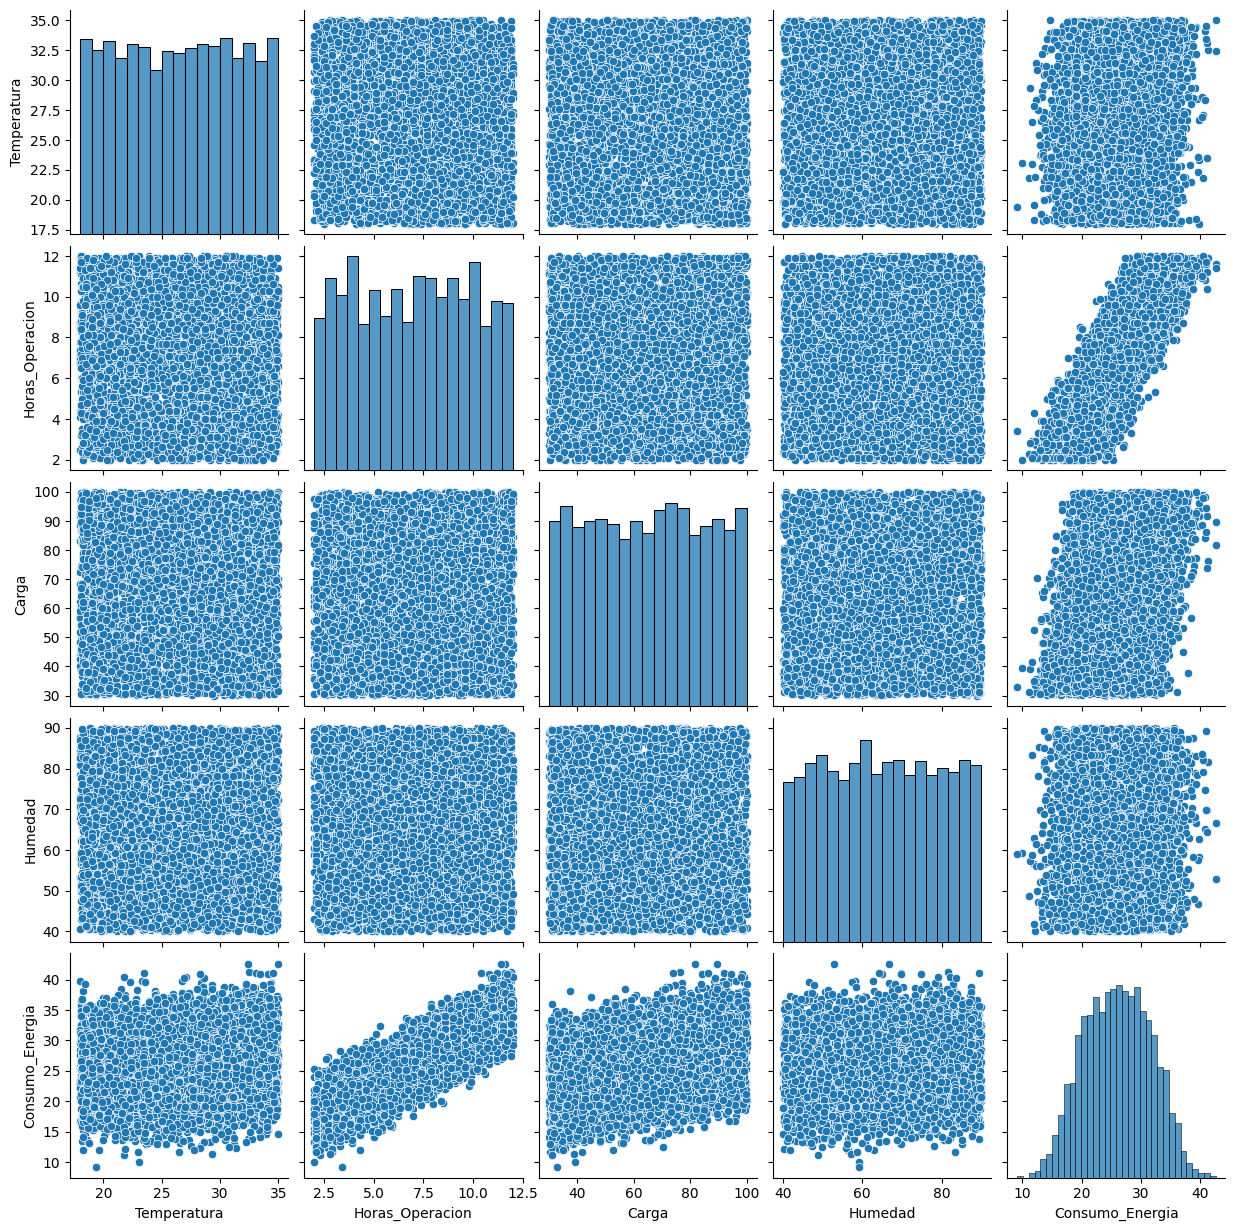

In [12]:
sns.pairplot(df)

<Axes: ylabel='Frequency'>

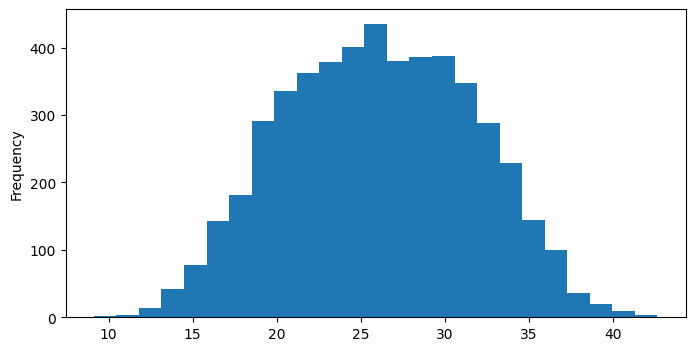

In [13]:
df["Consumo_Energia"].plot.hist(bins=25, figsize=(8,4)) # Hacer un histograma
# ¿Cómo se distribuyen los datos por intervalos?
# Por rango de la variable y su frecuencia

<Axes: ylabel='Density'>

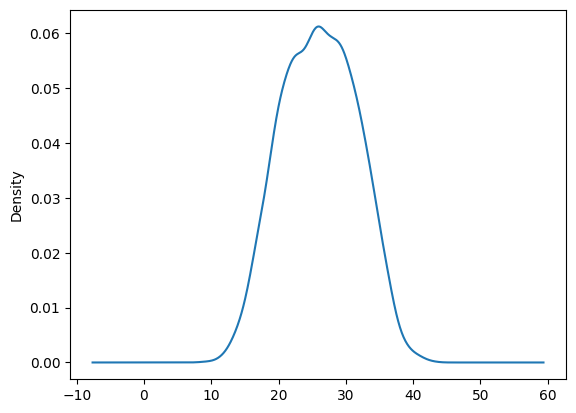

In [14]:
df["Consumo_Energia"].plot.density() # Observar la densidad
# ¿Dónde están concentrado los datos?
# - Al centro, similar al histograma

In [15]:
# Matriz de correlación
numeric_df = df.select_dtypes(include=[np.number])
numeric_df.corr().round(4)

,Temperatura,Horas_Operacion,Carga,Humedad,Consumo_Energia
Temperatura,1.0000,-0.0260,0.0102,0.0166,0.0978
Horas_Operacion,-0.0260,1.0000,-0.0099,0.0060,0.8434
Carga,0.0102,-0.0099,1.0000,0.0060,0.3366
Humedad,0.0166,0.0060,0.0060,1.0000,0.0627
Consumo_Energia,0.0978,0.8434,0.3366,0.0627,1.0000


<Axes: >

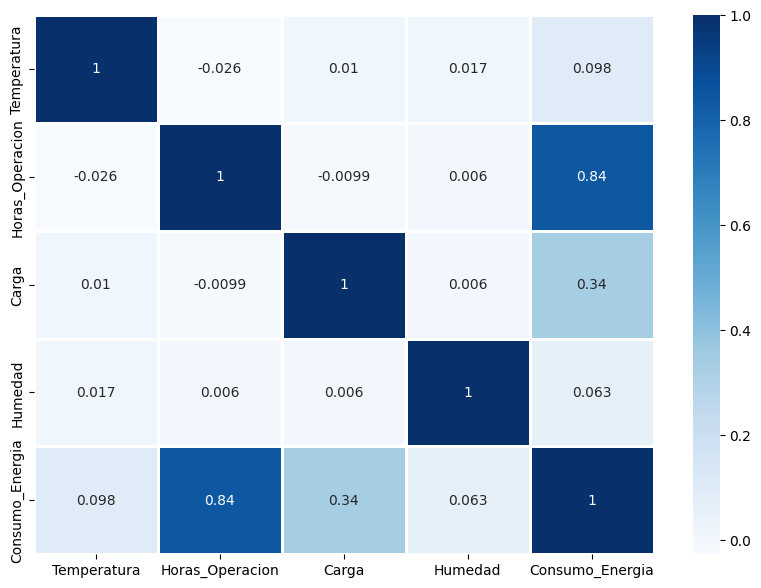

In [17]:
# Mapa de calor
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", linewidths = 2)

In [18]:
# Some variables
l_column = list(df.columns)
len_features = len(l_column)
l_column

['Temperatura', 'Horas_Operacion', 'Carga', 'Humedad', 'Consumo_Energia']

In [22]:
# Variables para entrenar
x = df[l_column[0:len_features - 1]]
y = df[l_column[len_features - 1]]
# x.head() x.head()

In [23]:
# Separar datos para entrenamiento
# 30% prueba, 70% entrenamiento
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 123)

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

ln = LinearRegression() # Utilizra el modelo de regresión lineal
ln.fit(x_train, y_train) # Ajustar y entrenar

LinearRegression()

In [31]:
print(ln.intercept_) # Intersección del modelo lineal
print(ln.coef_) # Coeficientes del modelo lineal

2.741067446117448
[0.13713677 1.66877804 0.09634816 0.02679108]


In [43]:
cdf = pd.DataFrame(data=ln.coef_, index=x_train.columns, columns=["Coeficientes"])
cdf

,Coeficientes
Temperatura,0.137137
Horas_Operacion,1.668778
Carga,0.096348
Humedad,0.026791


In [46]:
n = x_train.shape[0]
k = x_train.shape[1]
dfn = n-k
train_pref = ln.predict(x_train)

train_error = np.square(train_pref - y_train)
sum_error = np.sum(train_error)

se = [0, 0, 0, 0]

for i in range(k):
  r = (sum_error / dfn)
  r = r/np.sum(np.square(x_train[list(x_train.columns)[i]] - x_train[list(x_train.columns)[i]].mean()))
  se[i] = np.sqrt(r)

cdf["Error Estandar"] = se
cdf["Estadistica T"] = cdf["Coeficientes"]/cdf["Error Estandar"]

In [47]:
cdf.head()

,Coeficientes,Error Estandar,Estadistica T
Temperatura,0.137137,0.007557,18.147233
Horas_Operacion,1.668778,0.013138,127.020720
Carga,0.096348,0.001859,51.826973
Humedad,0.026791,0.002611,10.260097


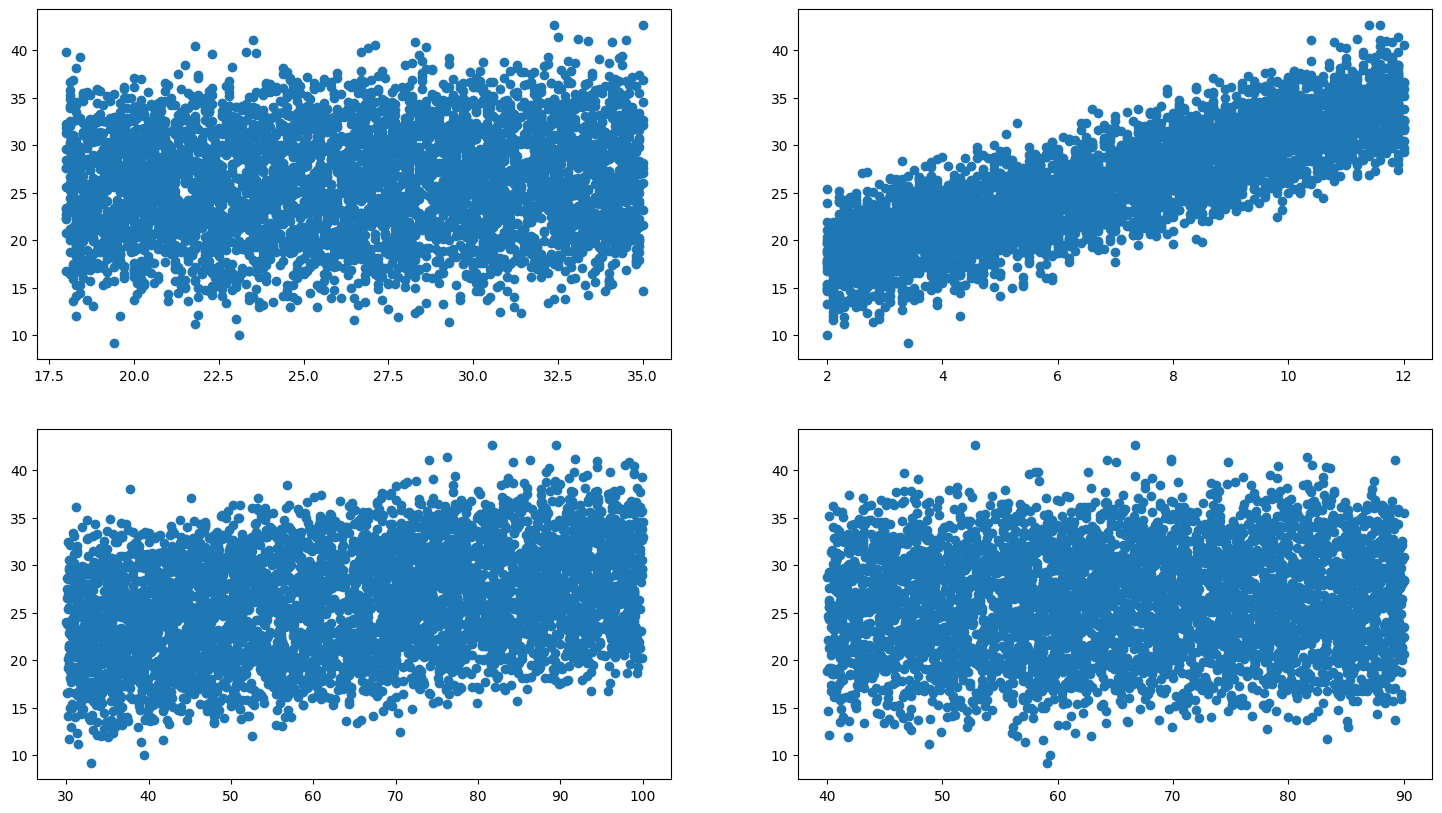

In [57]:
l = list(cdf.index)

from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]], df["Consumo_Energia"])
#ax0.set_title(l[0] + " vs. Consumo de energía", frontdict={"fontsize": 20})

ax0 = plt.subplot(gs[1])
ax0.scatter(df[l[1]], df["Consumo_Energia"])
#ax0.set_title(l[1] + " vs. Consumo de energía", frontdict={"fontsize": 20})

ax0 = plt.subplot(gs[2])
ax0.scatter(df[l[2]], df["Consumo_Energia"])
#ax0.set_title(l[2] + " vs. Consumo de energía", frontdict={"fontsize": 20})

ax0 = plt.subplot(gs[3])
ax0.scatter(df[l[3]], df["Consumo_Energia"])
#ax0.set_title(l[3] + " vs. Consumo de energía", frontdict={"fontsize": 20})

In [59]:
predictions = ln.predict(x_test)
print("Tipo de objeto predicho: ", type(predictions))
print("Tamaño del objeto predicho: ", predictions.shape)

Tipo de objeto predicho:  <class 'numpy.ndarray'>
Tamaño del objeto predicho:  (1500,)


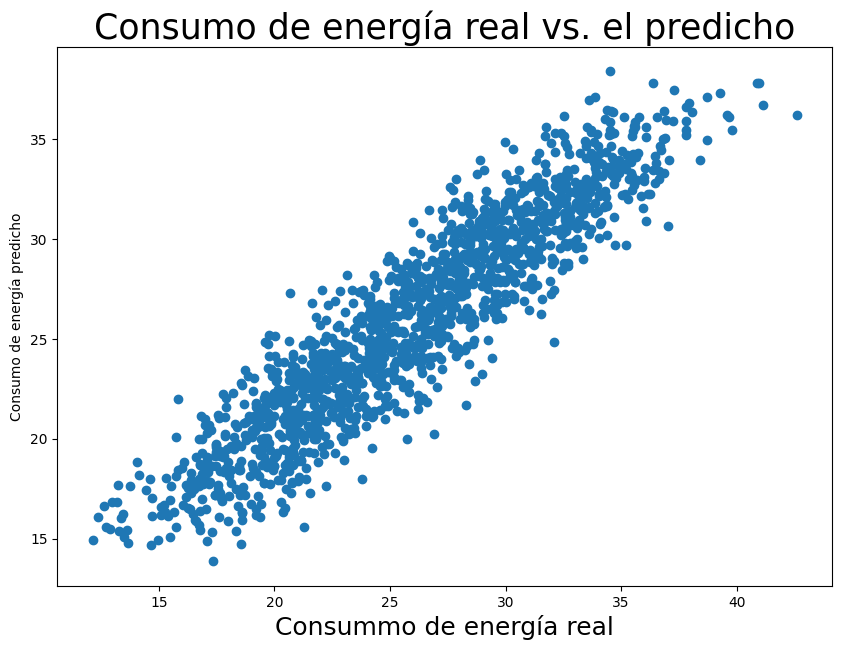

In [63]:
# Diagrama de dispersión
plt.figure(figsize = (10, 7))
plt.title("Consumo de energía real vs. el predicho", fontsize = 25)
plt.xlabel("Consummo de energía real", fontsize = 18)
plt.ylabel("Consumo de energía predicho", fontsize = 10)
plt.scatter(y_test, predictions) # Esto me lo dijo la IA
plt.show()

/tmp/ipykernel_868/3314565210.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test - predictions)


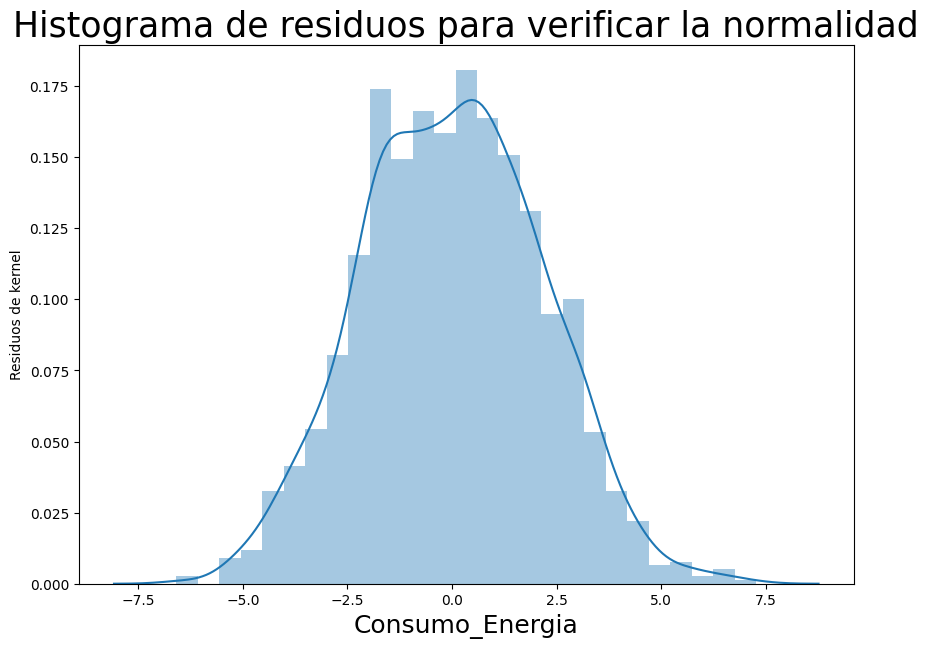

In [65]:
plt.figure(figsize = (10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize = 25)
plt.xlabel("Residuos", fontsize = 18)
plt.ylabel("Residuos de kernel", fontsize = 10)
sns.distplot(y_test - predictions)
plt.show()

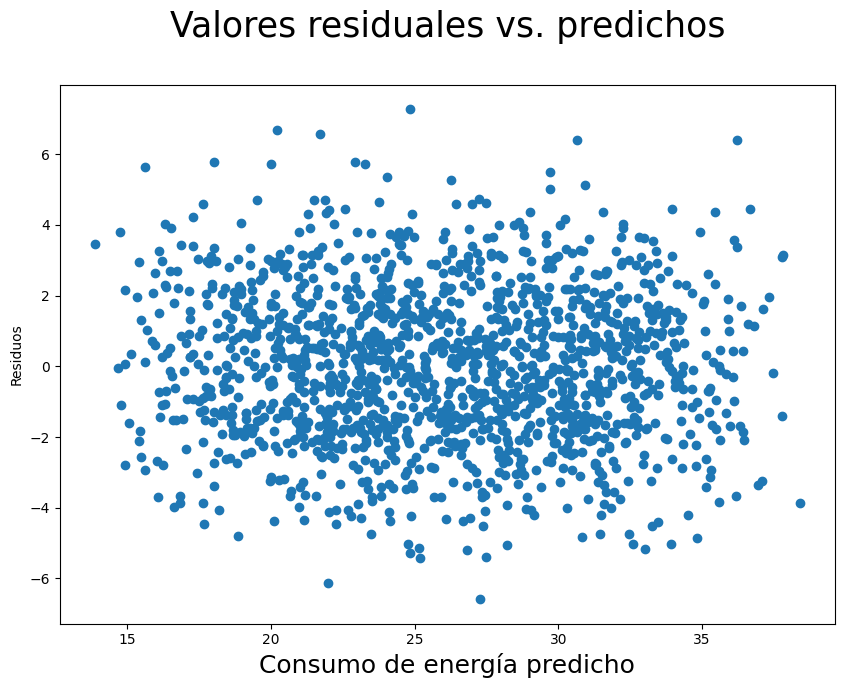

In [66]:
# Diagrama de dispersión
plt.figure(figsize = (10, 7))
plt.title("Valores residuales vs. predichos\n", fontsize = 25)
plt.xlabel("Consumo de energía predicho", fontsize = 18)
plt.ylabel("Residuos", fontsize = 10)
plt.scatter(x=predictions, y=y_test - predictions)

In [72]:
# Random forest
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

from sklearn.datasets import make_regression
n_samples = 100
n_features = 6
n_informative = 3



In [73]:
x, y, coef = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_informative, random_state=20, shuffle=False, noise=20, coef=True)

In [75]:
# Crear un dataframe artificial
df1 = pd.DataFrame(data=x, columns=["x"+str(i) for i in range(1, n_features + 1)])
df2 = pd.DataFrame(data = y, columns = ["y"])
df = pd.concat([df1, df2], axis = 1)
df.head(10)

,x1,x2,x3,x4,x5,x6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


In [76]:
with plt.style.context(("Solarize_Ligth2")):
  for i_col in enumerate(df.columns[: 1]):
    plt.figure(figsize = (0, 4))
    plt.grid(True)
    plt.xlabel("Feature:", + col, fontsize = 12)
    plt.ylabel("Output: y", fontsize = 12)
    plt.scatter(df[col], df["y"], c="red")

OSError: 'Solarize_Ligth2' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

In [79]:
import statsmodels.api as sm

xs = sm.add_constant(x)
stat_model = sm.OLS(y, xs)
stat_result = stat_model.fit()
print(stat_result.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        21:23:25   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0